# Model 1. 광고 고성과 예측 + 품질 점수화 + 등급화

## 모델 정의
광고 등록 시점에 확보 가능한 속성 정보만으로
최종 품질 점수 상위 25%에 해당하는 고성과 광고를 사전 예측하는 이진 분류 모델.
적용 대상은 유효 클릭(>=10건)이 확보된 광고로 제한한다.

## 진행 순서
1. 데이터 로드 및 사전 확인
2. 피처 그룹 정의
3. 피처 실험 (LightGBM 고정, val 기준)
4. 후보 피처 SHAP 사전 검증
5. 최적 피처 선정
6. 모델 비교 (val 기준)
7. 과적합 점검 (Learning Curve)
8. 최종 모델 선정 ([full] XGB 고정)
9. Optuna 하이퍼파라미터 튜닝 (val 기준)
10. 최종 평가 (test — 딱 한 번)
11. 민감도 분석 ([clean] test 성능 별도 제시)
12. SHAP 최종 해석
13. 품질 점수화
14. 등급화 (train+val cutpoint 기준으로 test 적용)
15. 최종 결과 요약

## 주요 설계 원칙
- 누수 방지: 피처는 등록 시점 속성만 사용. 성과 지표 절대 투입 금지
- is_outlier: 최종 성과 기반 값으로 등록 시점에 알 수 없음. 피처 투입 금지
- val: 모든 실험 판단 기준. 피처 선정/모델 선정/threshold 선정
- test: 최종 1회만 사용
- 최종 모델: [full] XGB 고정 (is_outlier가 사후 성과 기반이라 clean은 운영 불가)
- 등급화: train+val에서 점수 변환 함수와 cutpoint를 모두 확정한 뒤 test에만 적용
- 재현성: Optuna best_params는 JSON으로 저장해 재실행 시 미세 변동 방지

## 피처 해석
- 수치형: 핵심 예측 신호 (A_numeric 단독 val_auc 0.794)
- OHE: 수치형에 보조 정보 추가
- TF-IDF: 포함 조합(D_num+tfidf, C_full)이 val AUC 측면에서는 B_num+ohe 대비 더 높은 성능을 보였으나, 피처 수 증가, 해석성 저하, 운영 복잡도(텍스트 vectorizer 갱신·관리 부담)를 고려하여 B_num+ohe를 최종 채택. 본 모델은 최고 단일 성능보다 운영 안정성·해석성·단순성을 우선한 선택임


## 0. 환경 설정

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import re
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = r'C:\Users\hoo58\OneDrive\바탕 화면\tables\DATA\eda_ready_new' + '\\'
SEED = 42
CV   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
TARGET_AUC = 0.75
status_colors = {'SAFE': 'steelblue', 'CAUTION': 'goldenrod', 'RISK': 'tomato'}
print(f"목표 AUC: {TARGET_AUC}")


목표 AUC: 0.75


## 1. 데이터 로드 및 사전 확인

In [2]:

def clean_col_names_unique(df):
    df = df.copy()
    new_cols = []
    seen = {}
    for c in df.columns:
        clean = re.sub(r'[^A-Za-z0-9_]', '_', c)
        if clean in seen:
            seen[clean] += 1
            clean = f"{clean}_{seen[clean]}"
        else:
            seen[clean] = 0
        new_cols.append(clean)
    df.columns = new_cols
    return df

train = pd.read_parquet(BASE + 'model1_train.parquet')
val   = pd.read_parquet(BASE + 'model1_val.parquet')
test  = pd.read_parquet(BASE + 'model1_test.parquet')

train = clean_col_names_unique(train)
val   = clean_col_names_unique(val)
test  = clean_col_names_unique(test)

cat_cols = [c for c in train.columns if str(train[c].dtypes).startswith('category')]
if cat_cols:
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        # train에만 fit. val/test에 unseen category가 있으면 'unknown'으로 처리
        train_vals = train[col].astype(str).tolist()
        le.fit(train_vals + ['unknown'])
        le_dict[col] = le

        def safe_transform(series, le):
            known = set(le.classes_)
            return le.transform([v if v in known else 'unknown' for v in series.astype(str)])

        train[col] = safe_transform(train[col], le)
        val[col]   = safe_transform(val[col],   le)
        test[col]  = safe_transform(test[col],  le)
    print(f"LabelEncoder: train only fit, unseen -> 'unknown' 처리. 대상: {cat_cols}")

assert len(train.columns) == len(set(train.columns))

print(f"train: {train.shape} | 고성과 비율: {train['label'].mean()*100:.1f}%")
print(f"val:   {val.shape}   | 고성과 비율: {val['label'].mean()*100:.1f}%")
print(f"test:  {test.shape}  | 고성과 비율: {test['label'].mean()*100:.1f}%")

META_COLS    = ['ads_idx', 'label', 'is_outlier']
all_feat     = [c for c in train.columns if c not in META_COLS]
tfidf_feat   = [c for c in all_feat if c.startswith('tfidf_')]
ohe_feat     = [c for c in all_feat if any(
    c.startswith(p) for p in
    ['analysis_ads_type_label_', 'reward_band_', 'final_media_',
     'final_action_', 'ads_os_type_']
)]
numeric_feat = [c for c in all_feat if c not in tfidf_feat + ohe_feat]

print(f"\n수치형: {len(numeric_feat)}개 | OHE: {len(ohe_feat)}개 | TF-IDF: {len(tfidf_feat)}개")


LabelEncoder: train only fit, unseen -> 'unknown' 처리. 대상: ['ads_rejoin_type', 'ads_action_rule']
train: (2176, 101) | 고성과 비율: 25.0%
val:   (726, 101)   | 고성과 비율: 21.5%
test:  (726, 101)  | 고성과 비율: 25.1%

수치형: 14개 | OHE: 34개 | TF-IDF: 50개


In [3]:

LEAK_COLS = [
    'smoothed_cvr','total_margin','complete_cnt_f','avg_ctit_imputed',
    'log_margin','log_complete','log_ctit',
    'score_cvr','score_margin','score_complete','score_ctit',
    'quality_score_LABEL_ONLY','cvr_pct','click_cnt','complete_cnt',
    'early_cvr_raw','rule_based_decline',
]
leak_found = [c for c in LEAK_COLS if c in train.columns]
assert len(leak_found) == 0, f"누수 위험: {leak_found}"
assert 'is_outlier' not in all_feat
print("OK: 누수 체크 통과")
print(f"is_outlier: 최종 성과 기반 값 — 피처 투입 금지, row filtering 메타 컬럼으로만 사용")
print(f"train 이상치: {train['is_outlier'].sum():,}건 ({train['is_outlier'].mean()*100:.1f}%)")


OK: 누수 체크 통과
is_outlier: 최종 성과 기반 값 — 피처 투입 금지, row filtering 메타 컬럼으로만 사용
train 이상치: 78건 (3.6%)


## 2. 피처 그룹 정의

수치형 피처가 핵심 예측 신호이고 OHE가 보조 정보를 추가한다.
TF-IDF는 광고명/설명 텍스트 기반으로, 포함 조합(D_num+tfidf, C_full)이
val AUC 측면에서는 B_num+ohe 대비 더 높게 나오는 경향이 있다.

7가지 피처 조합을 모두 실험한 뒤 val_auc, 안정성, 운영 비용(피처 수,
텍스트 vectorizer 관리 부담), 해석성을 종합해 최적 조합을 선정한다.


In [4]:

ohe_no_action = [c for c in ohe_feat if not c.startswith('final_action_')]

FEATURE_SETS = {
    'A_numeric':         numeric_feat,
    'B_num+ohe':         numeric_feat + ohe_feat,
    'C_full':            numeric_feat + ohe_feat + tfidf_feat,
    'D_num+tfidf':       numeric_feat + tfidf_feat,
    'E_ohe_only':        ohe_feat,
    'F_no_action':       numeric_feat + ohe_no_action + tfidf_feat,
    'G_num+ohe_notfidf': numeric_feat + ohe_feat,
}

for name, feats in FEATURE_SETS.items():
    valid_feats = [f for f in feats if f in train.columns]
    print(f"  {name}: {len(valid_feats)}개")


  A_numeric: 14개
  B_num+ohe: 48개
  C_full: 98개
  D_num+tfidf: 64개
  E_ohe_only: 34개
  F_no_action: 90개
  G_num+ohe_notfidf: 48개


## 3. 피처 실험 (LightGBM 고정, val 기준)

모든 실험 판단은 val 기준으로 한다. test는 최종 1회만 사용.

과적합 판단 기준:
- SAFE:    gap <= 0.10, cv_std <= 0.03
- CAUTION: gap 0.10~0.15 또는 cv_std 0.03~0.05
- RISK:    gap > 0.15 또는 cv_std > 0.05

train_auc 단독으로 모델을 탈락시키지 않는다.
XGBoost/트리 계열은 train_auc가 높게 나오는 것이 자연스럽다.
cv_auc 안정성과 fold 편차를 함께 보고 종합 판단한다.


In [5]:

def run_feature_experiment(train_df, val_df, feature_sets, cv=CV, seed=42):
    results = []
    for exp_name, feats in feature_sets.items():
        valid_feats = [f for f in feats if f in train_df.columns]
        if not valid_feats:
            continue

        X_tr = train_df[valid_feats]
        y_tr = train_df['label']
        X_va = val_df[valid_feats]
        y_va = val_df['label']

        model = LGBMClassifier(
            n_estimators=300, class_weight='balanced',
            random_state=seed, verbose=-1, n_jobs=-1,
        )
        model.fit(X_tr, y_tr)

        tr_proba = model.predict_proba(X_tr)[:, 1]
        va_proba = model.predict_proba(X_va)[:, 1]
        tr_auc   = roc_auc_score(y_tr, tr_proba)
        va_auc   = roc_auc_score(y_va, va_proba)
        va_prauc = average_precision_score(y_va, va_proba)

        cv_fold = cross_val_score(
            LGBMClassifier(n_estimators=300, class_weight='balanced',
                           random_state=seed, verbose=-1, n_jobs=-1),
            X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1
        )
        gap = tr_auc - va_auc

        if gap <= 0.10 and cv_fold.std() <= 0.03:
            status = 'SAFE'
        elif gap <= 0.15 and cv_fold.std() <= 0.05:
            status = 'CAUTION'
        else:
            status = 'RISK'

        results.append({
            'experiment':  exp_name,
            'n_features':  len(valid_feats),
            'train_auc':   round(tr_auc, 4),
            'val_auc':     round(va_auc, 4),
            'val_prauc':   round(va_prauc, 4),
            'cv_mean':     round(cv_fold.mean(), 4),
            'cv_std':      round(cv_fold.std(), 4),
            'cv_min':      round(cv_fold.min(), 4),
            'cv_max':      round(cv_fold.max(), 4),
            'gap':         round(gap, 4),
            'status':      status,
        })
        print(f"{exp_name:22s} | val={va_auc:.4f} | cv={cv_fold.mean():.4f}±{cv_fold.std():.4f} "
              f"[{cv_fold.min():.3f}~{cv_fold.max():.3f}] | gap={gap:.4f} [{status}]")

    return pd.DataFrame(results)

print("=== 피처 실험 (이상치 포함, full) ===")
train_full = train.copy()
val_full   = val.copy()
result_full = run_feature_experiment(train_full, val_full, FEATURE_SETS)

print("\n=== 피처 실험 (이상치 제외, clean) ===")
train_clean = train[train['is_outlier'] == 0].copy()
val_clean   = val[val['is_outlier'] == 0].copy()
result_clean = run_feature_experiment(train_clean, val_clean, FEATURE_SETS)


=== 피처 실험 (이상치 포함, full) ===
A_numeric              | val=0.7886 | cv=0.7866±0.0272 [0.759~0.837] | gap=0.1314 [CAUTION]
B_num+ohe              | val=0.8047 | cv=0.8102±0.0228 [0.779~0.850] | gap=0.1316 [CAUTION]
C_full                 | val=0.8259 | cv=0.8293±0.0226 [0.802~0.859] | gap=0.1424 [CAUTION]
D_num+tfidf            | val=0.8250 | cv=0.8236±0.0275 [0.794~0.857] | gap=0.1385 [CAUTION]
E_ohe_only             | val=0.6331 | cv=0.6537±0.0156 [0.632~0.678] | gap=0.0474 [SAFE]
F_no_action            | val=0.8261 | cv=0.8254±0.0283 [0.793~0.863] | gap=0.1373 [CAUTION]
G_num+ohe_notfidf      | val=0.8047 | cv=0.8102±0.0228 [0.779~0.850] | gap=0.1316 [CAUTION]

=== 피처 실험 (이상치 제외, clean) ===
A_numeric              | val=0.8044 | cv=0.7957±0.0205 [0.764~0.821] | gap=0.1106 [CAUTION]
B_num+ohe              | val=0.8156 | cv=0.8091±0.0244 [0.771~0.847] | gap=0.1171 [CAUTION]
C_full                 | val=0.8395 | cv=0.8252±0.0185 [0.805~0.851] | gap=0.1272 [CAUTION]
D_num+tfidf            

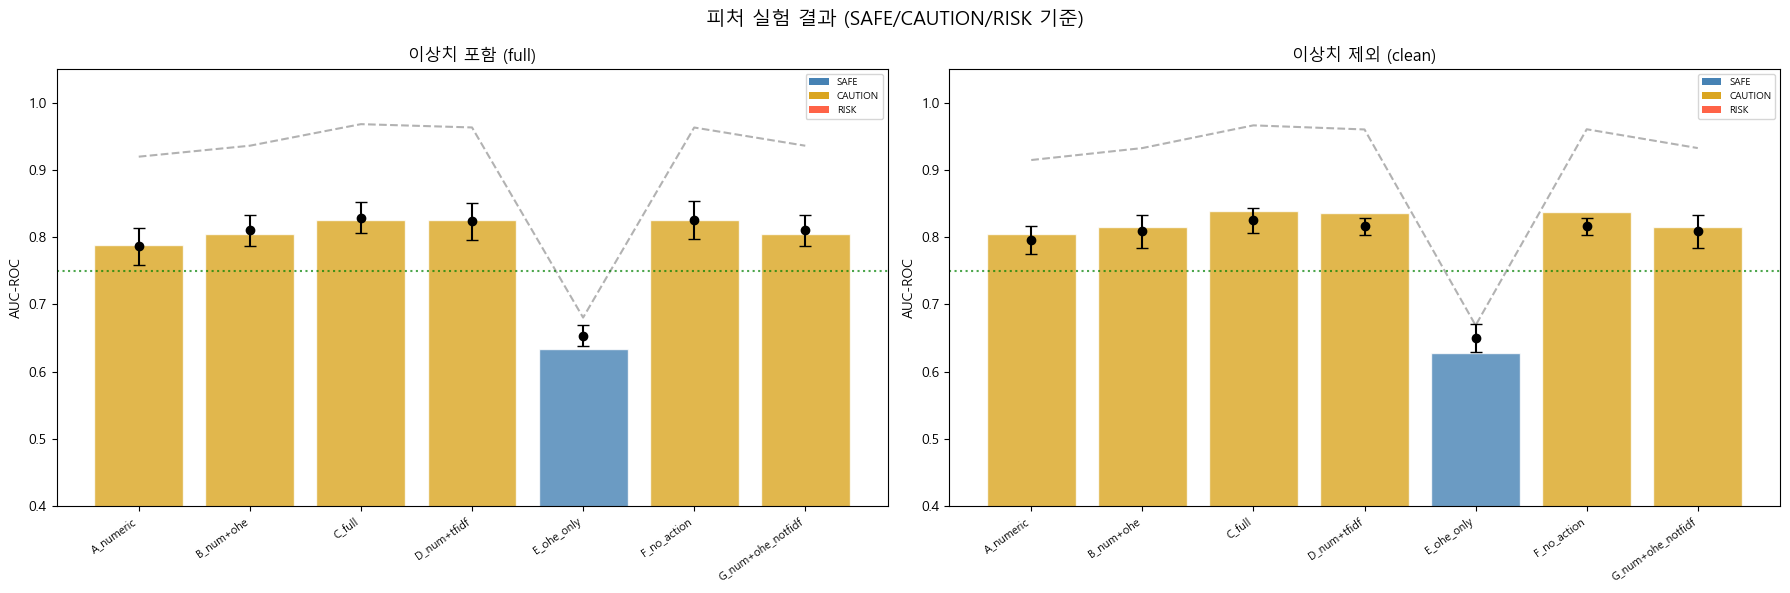


=== full 결과 (val_auc 정렬) ===
       experiment  n_features  train_auc  val_auc  cv_mean  cv_std  cv_min  cv_max    gap  status
      F_no_action          90     0.9634   0.8261   0.8254  0.0283  0.7933  0.8625 0.1373 CAUTION
           C_full          98     0.9684   0.8259   0.8293  0.0226  0.8017  0.8590 0.1424 CAUTION
      D_num+tfidf          64     0.9635   0.8250   0.8236  0.0275  0.7938  0.8572 0.1385 CAUTION
G_num+ohe_notfidf          48     0.9363   0.8047   0.8102  0.0228  0.7789  0.8499 0.1316 CAUTION
        B_num+ohe          48     0.9363   0.8047   0.8102  0.0228  0.7789  0.8499 0.1316 CAUTION
        A_numeric          14     0.9200   0.7886   0.7866  0.0272  0.7587  0.8369 0.1314 CAUTION
       E_ohe_only          34     0.6805   0.6331   0.6537  0.0156  0.6317  0.6778 0.0474    SAFE


In [6]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('피처 실험 결과 (SAFE/CAUTION/RISK 기준)', fontsize=14)

for ax, result, title in [
    (axes[0], result_full,  '이상치 포함 (full)'),
    (axes[1], result_clean, '이상치 제외 (clean)'),
]:
    x = range(len(result))
    colors = [status_colors[s] for s in result['status']]
    ax.bar(x, result['val_auc'], color=colors, alpha=0.8, edgecolor='white')
    ax.errorbar(x, result['cv_mean'], yerr=result['cv_std'],
                fmt='o', color='black', capsize=4, label='CV AUC')
    ax.plot(x, result['train_auc'], 'k--', alpha=0.3, label='train AUC')
    ax.axhline(TARGET_AUC, color='green', linestyle=':', alpha=0.7, label=f'목표 {TARGET_AUC}')
    ax.set_xticks(x)
    ax.set_xticklabels(result['experiment'], rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('AUC-ROC')
    ax.set_title(title)
    ax.set_ylim(0.4, 1.05)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='steelblue', label='SAFE'),
        Patch(facecolor='goldenrod', label='CAUTION'),
        Patch(facecolor='tomato',    label='RISK'),
    ] + ax.get_legend_handles_labels()[0][3:], fontsize=7)

plt.tight_layout()
plt.show()

print("\n=== full 결과 (val_auc 정렬) ===")
print(result_full[['experiment','n_features','train_auc','val_auc','cv_mean',
                    'cv_std','cv_min','cv_max','gap','status']]
      .sort_values('val_auc', ascending=False).to_string(index=False))


## 4. 후보 피처 SHAP 사전 검증

모델 선정 전에 피처 후보(B_num+ohe, E_ohe_only)에 대해 SHAP을 먼저 확인한다.
상위 피처가 누수 의심 피처(early_complete, early_cvr 등)에 몰리면 해당 실험을 탈락시킨다.
수치형/OHE 등 등록 시점 속성이 상위에 고르게 분포해야 정상이다.


In [7]:

try:
    import shap

    candidates = {
        'B_num+ohe': [f for f in FEATURE_SETS['B_num+ohe'] if f in train.columns],
        'E_ohe_only': [f for f in FEATURE_SETS['E_ohe_only'] if f in train.columns],
    }

    for name, feats in candidates.items():
        X_tr = train_full[feats]
        y_tr = train_full['label']
        X_va = val_full[feats]
        y_va = val_full['label']

        m = LGBMClassifier(n_estimators=300, class_weight='balanced',
                            random_state=SEED, verbose=-1, n_jobs=-1)
        m.fit(X_tr, y_tr)

        explainer   = shap.TreeExplainer(m)
        shap_values = explainer.shap_values(X_va)
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values

        mean_abs = np.abs(sv).mean(0)
        top10    = sorted(zip(feats, mean_abs), key=lambda x: -x[1])[:10]

        print(f"\n[{name}] SHAP 상위 10개:")
        LEAK_FEATS = ['early_complete','early_cvr','complete_day1',
                       'complete_day2','complete_day3']
        for rank, (feat, val_shap) in enumerate(top10, 1):
            warn = " <- 누수 의심" if any(lf in feat for lf in LEAK_FEATS) else ""
            print(f"  {rank:2d}. {feat}: {val_shap:.4f}{warn}")

        top3 = [f for f, _ in top10[:3]]
        leak_top3 = [f for f in top3 if any(lf in f for lf in LEAK_FEATS)]
        if leak_top3:
            print(f"  경고: 상위 3개에 누수 의심 피처 포함 -> {leak_top3}")
        else:
            print(f"  OK: 상위 3개에 누수 의심 피처 없음")

except ImportError:
    print("pip install shap 후 재실행")



[B_num+ohe] SHAP 상위 10개:
   1. ads_reward_price: 1.3119
   2. reg_hour: 0.9378
   3. ads_order: 0.8237
   4. reg_weekday_enc: 0.5570
   5. final_action_action_run: 0.3237
   6. ads_rejoin_type: 0.2887
   7. final_media_media_naver: 0.2775
   8. ads_require_adid: 0.2480
   9. final_action_action_click: 0.2232
  10. mentioned_media_cnt: 0.2141
  OK: 상위 3개에 누수 의심 피처 없음

[E_ohe_only] SHAP 상위 10개:
   1. final_action_action_run: 0.4918
   2. reward_band_500____: 0.4367
   3. reward_band_50____: 0.3480
   4. analysis_ads_type_label_____5: 0.2856
   5. final_media_media_naver: 0.1691
   6. ads_os_type_7: 0.1426
   7. final_action_action_signup: 0.1322
   8. ads_os_type_2: 0.0863
   9. final_media_media_app: 0.0862
  10. final_media_media_unknown: 0.0795
  OK: 상위 3개에 누수 의심 피처 없음


## 5. 최적 피처 선정

선정 정책:
1. 안정성 조건 충족 (gap <= 0.15, cv_std <= 0.05, SHAP 누수 의심 없음)
2. 위 조건 안에서 운영 단순성·해석성을 우선해 B_num+ohe를 1순위로 검토
3. B_num+ohe가 안정성 조건 미충족 시에만 전체에서 val_auc 최고를 선택

참고: TF-IDF 포함 조합(D_num+tfidf, C_full)이 val AUC는 더 높지만
피처 수 증가와 텍스트 vectorizer 운영 부담을 고려해 채택하지 않는다.
즉, 최고 단일 성능이 아니라 운영 안정성·해석성·단순성을 우선한 선택이다.


In [8]:

def select_best(result_df, prefer_exp='B_num+ohe', max_gap=0.15, max_cv_std=0.05):
    """
    안정성 조건 충족 시 운영 단순성·해석성을 우선해 prefer_exp를 채택.
    조건 미충족 시에만 전체에서 val_auc 최고를 선택.
    """
    prefer_row = result_df[result_df['experiment'] == prefer_exp]
    if len(prefer_row) > 0:
        r = prefer_row.iloc[0]
        if r['gap'] <= max_gap and r['cv_std'] <= max_cv_std:
            print(f"{prefer_exp} 안정성 조건 충족 -> 채택 (운영 단순성·해석성 우선)")
            print(f"  val_auc={r['val_auc']:.4f}, gap={r['gap']:.4f}, cv_std={r['cv_std']:.4f}")
            # 참고: 동일 조건 안에서 더 높은 val_auc 후보가 있는지 표시
            higher = result_df[(result_df['gap'] <= max_gap) &
                                (result_df['cv_std'] <= max_cv_std) &
                                (result_df['val_auc'] > r['val_auc'])]
            if not higher.empty:
                top = higher.sort_values('val_auc', ascending=False).iloc[0]
                print(f"  참고: val_auc 더 높은 후보 존재 -> {top['experiment']} "
                      f"(val_auc={top['val_auc']:.4f}, n_features={top['n_features']})")
                print(f"        피처 수 증가·해석성 저하·운영 비용으로 미채택")
            return r

    cands = result_df[
        (result_df['gap'] <= max_gap) &
        (result_df['cv_std'] <= max_cv_std)
    ]
    if cands.empty:
        cands = result_df[result_df['gap'] <= 0.20]
    if cands.empty:
        cands = result_df
    best = cands.sort_values('val_auc', ascending=False).iloc[0]
    if best['experiment'] != prefer_exp:
        print(f"{prefer_exp} 안정성 조건 미충족 -> {best['experiment']} 선택")
    return best

best_full  = select_best(result_full)
best_clean = select_best(result_clean)

print(f"\n[full]  최적: {best_full['experiment']} | val={best_full['val_auc']:.4f} | status={best_full['status']}")
print(f"[clean] 최적: {best_clean['experiment']} | val={best_clean['val_auc']:.4f} | status={best_clean['status']}")

BEST_EXP_FULL  = best_full['experiment']
BEST_EXP_CLEAN = best_clean['experiment']
BEST_FEATS_FULL  = [f for f in FEATURE_SETS[BEST_EXP_FULL]  if f in train.columns]
BEST_FEATS_CLEAN = [f for f in FEATURE_SETS[BEST_EXP_CLEAN] if f in train.columns]


B_num+ohe 안정성 조건 충족 -> 채택 (운영 단순성·해석성 우선)
  val_auc=0.8047, gap=0.1316, cv_std=0.0228
  참고: val_auc 더 높은 후보 존재 -> F_no_action (val_auc=0.8261, n_features=90)
        피처 수 증가·해석성 저하·운영 비용으로 미채택
B_num+ohe 안정성 조건 충족 -> 채택 (운영 단순성·해석성 우선)
  val_auc=0.8156, gap=0.1171, cv_std=0.0244
  참고: val_auc 더 높은 후보 존재 -> C_full (val_auc=0.8395, n_features=98)
        피처 수 증가·해석성 저하·운영 비용으로 미채택

[full]  최적: B_num+ohe | val=0.8047 | status=CAUTION
[clean] 최적: B_num+ohe | val=0.8156 | status=CAUTION


## 6. 모델 비교 (val 기준)

In [9]:

def compare_models(train_df, val_df, features, version_name, cv=CV, seed=42):
    X_tr = train_df[features]
    y_tr = train_df['label']
    X_va = val_df[features]
    y_va = val_df['label']

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    spw = neg / pos

    models = {
        'LR':   Pipeline([('sc', StandardScaler()),
                           ('clf', LogisticRegression(class_weight='balanced',
                                                       max_iter=1000, random_state=seed))]),
        'RF':   RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                        random_state=seed, n_jobs=-1),
        'LGBM': LGBMClassifier(n_estimators=300, class_weight='balanced',
                                random_state=seed, verbose=-1, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, scale_pos_weight=spw,
                               eval_metric='logloss', random_state=seed,
                               verbosity=0, n_jobs=-1),
    }

    results, fitted, probas = [], {}, {}
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        tr_p = model.predict_proba(X_tr)[:, 1]
        va_p = model.predict_proba(X_va)[:, 1]

        tr_auc   = roc_auc_score(y_tr, tr_p)
        va_auc   = roc_auc_score(y_va, va_p)
        va_prauc = average_precision_score(y_va, va_p)
        cv_scores= cross_val_score(model, X_tr, y_tr, cv=cv,
                                    scoring='roc_auc', n_jobs=-1)
        gap = tr_auc - va_auc

        if gap <= 0.10 and cv_scores.std() <= 0.03:
            status = 'SAFE'
        elif gap <= 0.15 and cv_scores.std() <= 0.05:
            status = 'CAUTION'
        else:
            status = 'RISK'

        results.append({
            'version': version_name, 'model': name,
            'train_auc':  round(tr_auc, 4),
            'val_auc':    round(va_auc, 4),
            'val_prauc':  round(va_prauc, 4),
            'cv_mean':    round(cv_scores.mean(), 4),
            'cv_std':     round(cv_scores.std(), 4),
            'cv_min':     round(cv_scores.min(), 4),
            'cv_max':     round(cv_scores.max(), 4),
            'gap':        round(gap, 4),
            'status':     status,
        })
        fitted[name] = model
        probas[name] = va_p
        print(f"  {name}: val={va_auc:.4f} | cv={cv_scores.mean():.4f}±{cv_scores.std():.4f} "
              f"[{cv_scores.min():.3f}~{cv_scores.max():.3f}] | gap={gap:.4f} [{status}]")

    return pd.DataFrame(results), fitted, probas, X_va, y_va

print("=== 모델 비교 (full) ===")
df_cmp_full, models_full, probas_full, X_va_full, y_va_full = compare_models(
    train_full, val_full, BEST_FEATS_FULL, 'full')

print("\n=== 모델 비교 (clean) ===")
df_cmp_clean, models_clean, probas_clean, X_va_clean, y_va_clean = compare_models(
    train_clean, val_clean, BEST_FEATS_CLEAN, 'clean')

df_all = pd.concat([df_cmp_full, df_cmp_clean], ignore_index=True)
print("\n=== 전체 모델 비교 (val_auc 정렬) ===")
print(df_all[['version','model','train_auc','val_auc','cv_mean','cv_std',
               'cv_min','cv_max','gap','status']]
      .sort_values('val_auc', ascending=False).to_string(index=False))


=== 모델 비교 (full) ===
  LR: val=0.7080 | cv=0.7214±0.0236 [0.690~0.763] | gap=0.0307 [SAFE]
  RF: val=0.7942 | cv=0.7905±0.0129 [0.777~0.812] | gap=0.1374 [CAUTION]
  LGBM: val=0.8047 | cv=0.8102±0.0228 [0.779~0.850] | gap=0.1316 [CAUTION]
  XGB: val=0.8082 | cv=0.8112±0.0217 [0.781~0.846] | gap=0.1290 [CAUTION]

=== 모델 비교 (clean) ===
  LR: val=0.7066 | cv=0.7084±0.0297 [0.675~0.760] | gap=0.0318 [SAFE]
  RF: val=0.8019 | cv=0.8004±0.0187 [0.781~0.835] | gap=0.1268 [CAUTION]
  LGBM: val=0.8156 | cv=0.8091±0.0244 [0.771~0.847] | gap=0.1171 [CAUTION]
  XGB: val=0.8224 | cv=0.8103±0.0207 [0.783~0.845] | gap=0.1111 [CAUTION]

=== 전체 모델 비교 (val_auc 정렬) ===
version model  train_auc  val_auc  cv_mean  cv_std  cv_min  cv_max    gap  status
  clean   XGB     0.9335   0.8224   0.8103  0.0207  0.7826  0.8451 0.1111 CAUTION
  clean  LGBM     0.9328   0.8156   0.8091  0.0244  0.7713  0.8467 0.1171 CAUTION
   full   XGB     0.9372   0.8082   0.8112  0.0217  0.7812  0.8458 0.1290 CAUTION
   full  LGBM

## 7. 과적합 점검 (Learning Curve)

full  최고 모델: XGB
clean 최고 모델: XGB


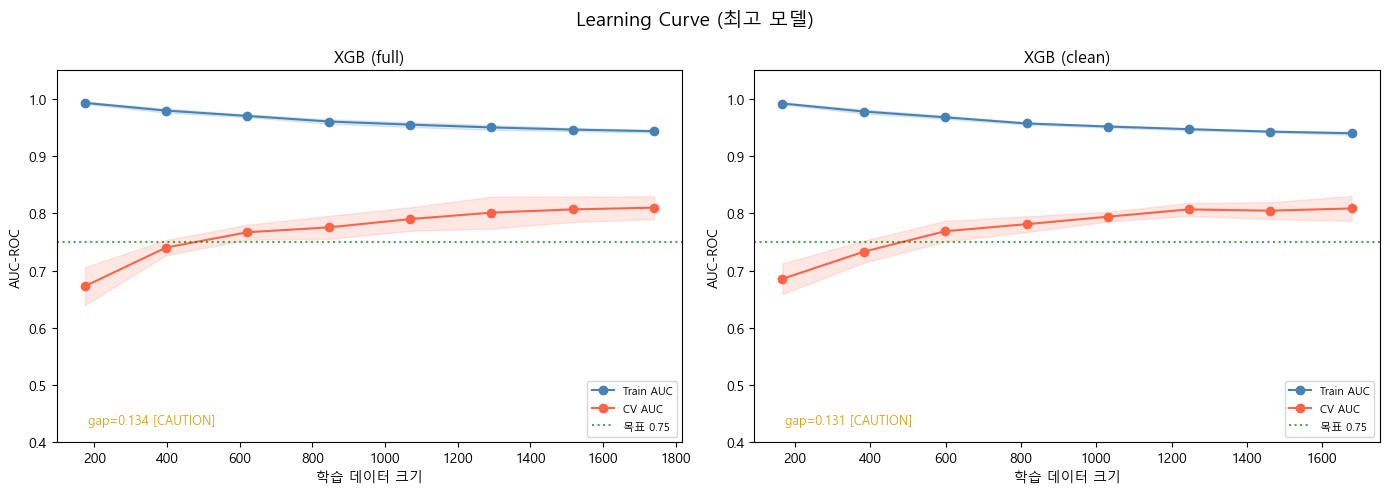

In [10]:

best_name_full  = df_cmp_full.sort_values('val_auc', ascending=False).iloc[0]['model']
best_name_clean = df_cmp_clean.sort_values('val_auc', ascending=False).iloc[0]['model']
print(f"full  최고 모델: {best_name_full}")
print(f"clean 최고 모델: {best_name_clean}")

def plot_lc(model, X, y, title, ax, cv=CV):
    sizes, tr_s, cv_s = learning_curve(
        model, X, y, cv=cv, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    tr_m, tr_std = tr_s.mean(1), tr_s.std(1)
    cv_m, cv_std = cv_s.mean(1), cv_s.std(1)

    ax.plot(sizes, tr_m, 'o-', color='steelblue', label='Train AUC')
    ax.fill_between(sizes, tr_m-tr_std, tr_m+tr_std, alpha=0.15, color='steelblue')
    ax.plot(sizes, cv_m, 'o-', color='tomato', label='CV AUC')
    ax.fill_between(sizes, cv_m-cv_std, cv_m+cv_std, alpha=0.15, color='tomato')
    ax.axhline(TARGET_AUC, color='green', linestyle=':', alpha=0.7, label=f'목표 {TARGET_AUC}')
    ax.set_xlabel('학습 데이터 크기')
    ax.set_ylabel('AUC-ROC')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(0.4, 1.05)

    gap = tr_m[-1] - cv_m[-1]
    color  = 'green' if gap<=0.10 else 'goldenrod' if gap<=0.15 else 'red'
    status = 'SAFE' if gap<=0.10 else 'CAUTION' if gap<=0.15 else 'RISK'
    ax.text(0.05, 0.05, f'gap={gap:.3f} [{status}]',
            transform=ax.transAxes, color=color, fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve (최고 모델)', fontsize=14)
plot_lc(models_full[best_name_full],
        train_full[BEST_FEATS_FULL], train_full['label'],
        f'{best_name_full} (full)', axes[0])
plot_lc(models_clean[best_name_clean],
        train_clean[BEST_FEATS_CLEAN], train_clean['label'],
        f'{best_name_clean} (clean)', axes[1])
plt.tight_layout()
plt.show()


## 8. 최종 모델 선정 — [full] XGB 고정

is_outlier는 최종 성과(CVR, 클릭수, 마진) 기반으로 만들어진 값이다.
광고 등록 시점에는 알 수 없는 사후 정보이므로,
실제 운영에서 clean 버전(이상치 제외)으로 예측하는 것은 불가능하다.

따라서 최종 운영 모델은 [full] XGB로 고정한다.
[clean] 결과는 이상치 제외 민감도 분석으로 Step 11에서 별도 제시한다.


In [11]:

# [full] XGB 강제 고정
FINAL_VERSION   = 'full'
FINAL_MODEL     = 'XGB'
FINAL_TRAIN     = train_full
FINAL_VAL       = val_full
FINAL_FEATS     = BEST_FEATS_FULL
FINAL_MODEL_OBJ = models_full['XGB']

xgb_row = df_cmp_full[df_cmp_full['model'] == 'XGB'].iloc[0]
print(f"최종 선정: [{FINAL_VERSION}] {FINAL_MODEL}")
print(f"  val_auc   = {xgb_row['val_auc']:.4f}")
print(f"  cv_mean   = {xgb_row['cv_mean']:.4f} ± {xgb_row['cv_std']:.4f}")
print(f"  cv range  = [{xgb_row['cv_min']:.3f} ~ {xgb_row['cv_max']:.3f}]")
print(f"  gap       = {xgb_row['gap']:.4f} [{xgb_row['status']}]")
gap_to_target = TARGET_AUC - xgb_row['val_auc']
auc_status = '달성' if xgb_row['val_auc'] >= TARGET_AUC else f'미달 ({gap_to_target:.4f} 부족)'
print(f"  목표 AUC {TARGET_AUC}: {auc_status}")
print(f"\n[full] 선정 근거")
print(f"  is_outlier는 최종 성과 기반 사후 정보")
print(f"  등록 시점에 알 수 없어 운영에서 clean 적용 불가")
print(f"  [clean] 결과는 Step 11 민감도 분석에서 별도 제시")


최종 선정: [full] XGB
  val_auc   = 0.8082
  cv_mean   = 0.8112 ± 0.0217
  cv range  = [0.781 ~ 0.846]
  gap       = 0.1290 [CAUTION]
  목표 AUC 0.75: 달성

[full] 선정 근거
  is_outlier는 최종 성과 기반 사후 정보
  등록 시점에 알 수 없어 운영에서 clean 적용 불가
  [clean] 결과는 Step 11 민감도 분석에서 별도 제시


## 9. Optuna 하이퍼파라미터 튜닝 (val 기준)

In [12]:

import json
import os

X_tune = FINAL_TRAIN[FINAL_FEATS]
y_tune = FINAL_TRAIN['label']
X_va_f = FINAL_VAL[FINAL_FEATS]
y_va_f = FINAL_VAL['label']

neg = (y_tune == 0).sum()
pos = (y_tune == 1).sum()
spw = neg / pos

BEST_PARAMS_PATH = 'model1_best_params.json'

def objective_xgb(trial):
    p = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'scale_pos_weight': spw, 'eval_metric': 'logloss',
        'random_state': SEED, 'verbosity': 0, 'n_jobs': -1,
    }
    return cross_val_score(XGBClassifier(**p), X_tune, y_tune,
                           cv=CV, scoring='roc_auc', n_jobs=-1).mean()

# best_params JSON이 존재하면 재사용, 없으면 Optuna 실행 후 저장
# (재실행 간 미세 변동을 막아 보고서-노트북 수치를 일치시키는 단일 진실 소스 역할)
if os.path.exists(BEST_PARAMS_PATH):
    with open(BEST_PARAMS_PATH, 'r') as f:
        best_params_raw = json.load(f)
    print(f"기존 best_params 로드: {BEST_PARAMS_PATH}")
    print(f"(Optuna 재실행을 원하면 해당 파일을 삭제하고 셀을 다시 실행)")
    # 로드된 파라미터로 CV AUC 재현
    best_cv_value = cross_val_score(
        XGBClassifier(**best_params_raw, scale_pos_weight=spw, eval_metric='logloss',
                      random_state=SEED, verbosity=0, n_jobs=-1),
        X_tune, y_tune, cv=CV, scoring='roc_auc', n_jobs=-1
    ).mean()
    print(f"CV AUC (재현): {best_cv_value:.4f}")
else:
    print("XGB Optuna 튜닝 시작 (100 trials)...")
    study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
    best_params_raw = study.best_params
    best_cv_value   = study.best_value
    print(f"\n최적 CV AUC: {best_cv_value:.4f}")

    with open(BEST_PARAMS_PATH, 'w') as f:
        json.dump(best_params_raw, f, indent=2)
    print(f"best_params 저장: {BEST_PARAMS_PATH}")

print(f"목표 AUC {TARGET_AUC}: {'달성' if best_cv_value >= TARGET_AUC else '미달'}")
print(f"\n[best_params]")
for k, v in best_params_raw.items():
    print(f"  {k}: {v}")


기존 best_params 로드: model1_best_params.json
(Optuna 재실행을 원하면 해당 파일을 삭제하고 셀을 다시 실행)
CV AUC (재현): 0.8190
목표 AUC 0.75: 달성

[best_params]
  n_estimators: 643
  learning_rate: 0.22329916619526158
  max_depth: 8
  subsample: 0.9247734590358337
  colsample_bytree: 0.6795292369167751
  gamma: 1.0524097192151365
  reg_alpha: 0.00044108827063748764
  reg_lambda: 0.10506932611511502
  min_child_weight: 4


In [13]:

# 저장된 best_params_raw를 사용해 모델 빌드 (study.best_params 직접 참조 X)
best_params = best_params_raw.copy()
best_params.update({'scale_pos_weight': spw, 'eval_metric': 'logloss',
                     'random_state': SEED, 'verbosity': 0, 'n_jobs': -1})
tuned_model = XGBClassifier(**best_params)
tuned_model.fit(X_tune, y_tune)

va_proba_tuned  = tuned_model.predict_proba(X_va_f)[:, 1]
tr_proba_tuned  = tuned_model.predict_proba(X_tune)[:, 1]
va_proba_before = FINAL_MODEL_OBJ.predict_proba(X_va_f)[:, 1]
gap_tuned = roc_auc_score(y_tune, tr_proba_tuned) - roc_auc_score(y_va_f, va_proba_tuned)

print("[튜닝 전후 val 성능 비교]")
print(f"  val AUC:   {roc_auc_score(y_va_f, va_proba_before):.4f} -> {roc_auc_score(y_va_f, va_proba_tuned):.4f}")
print(f"  val PR-AUC:{average_precision_score(y_va_f, va_proba_before):.4f} -> {average_precision_score(y_va_f, va_proba_tuned):.4f}")
print(f"  train-val gap: {gap_tuned:.4f} ({'SAFE' if gap_tuned<=0.10 else 'CAUTION' if gap_tuned<=0.15 else 'RISK'})")
gap_to_target = TARGET_AUC - roc_auc_score(y_va_f, va_proba_tuned)
auc_status = '달성' if roc_auc_score(y_va_f, va_proba_tuned) >= TARGET_AUC else f'미달 ({gap_to_target:.4f} 부족)'
print(f"  목표 AUC {TARGET_AUC}: {auc_status}")


[튜닝 전후 val 성능 비교]
  val AUC:   0.8082 -> 0.8094
  val PR-AUC:0.5824 -> 0.5848
  train-val gap: 0.1031 (CAUTION)
  목표 AUC 0.75: 달성


## 10. 최종 평가 (test — 딱 한 번)

[full] XGB로 test set 최종 평가.
val 기준으로 모든 실험이 완료된 후 test를 딱 한 번만 사용한다.


[최종 test 결과 — [full] XGB]
  AUC-ROC:       0.8347
  PR-AUC:        0.6221
  train-test gap:0.0777 (SAFE)
  목표 AUC 0.75: 달성


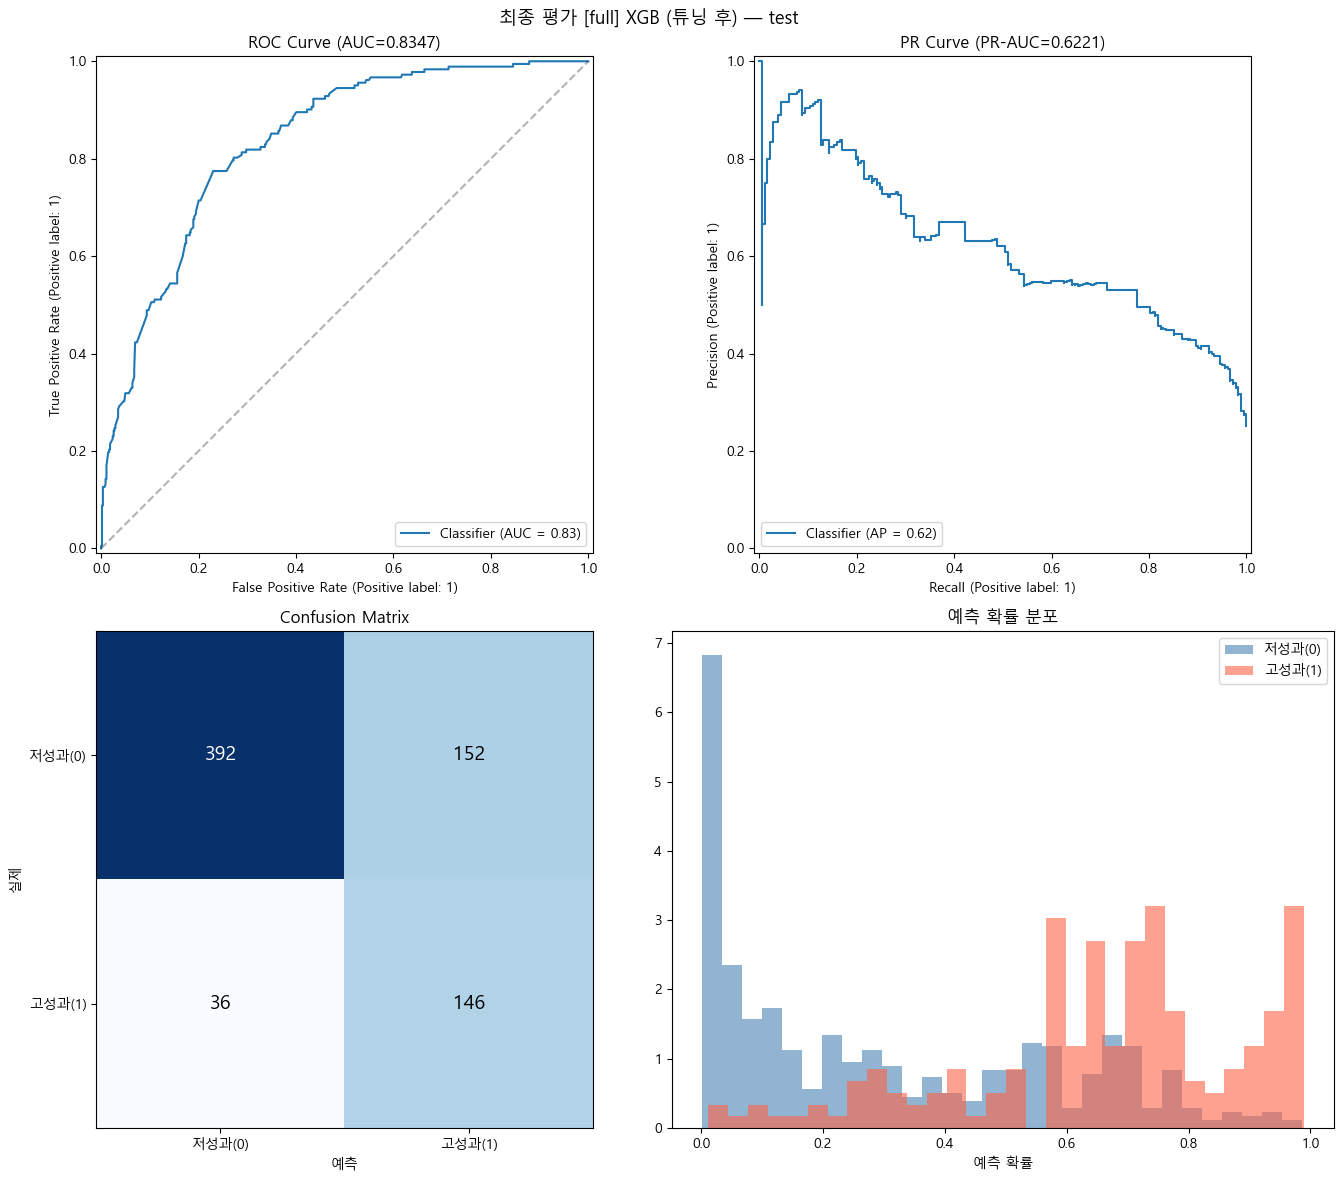


=== Classification Report ===
              precision    recall  f1-score   support

      저성과(0)       0.92      0.72      0.81       544
      고성과(1)       0.49      0.80      0.61       182

    accuracy                           0.74       726
   macro avg       0.70      0.76      0.71       726
weighted avg       0.81      0.74      0.76       726



In [14]:

test_final   = test.copy()  # full: 이상치 포함 전체
X_test_final = test_final[FINAL_FEATS]
y_test_final = test_final['label']

te_proba = tuned_model.predict_proba(X_test_final)[:, 1]
te_pred  = tuned_model.predict(X_test_final)
te_auc   = roc_auc_score(y_test_final, te_proba)
te_prauc = average_precision_score(y_test_final, te_proba)
te_gap   = roc_auc_score(y_tune, tr_proba_tuned) - te_auc

print(f"[최종 test 결과 — [full] XGB]")
print(f"  AUC-ROC:       {te_auc:.4f}")
print(f"  PR-AUC:        {te_prauc:.4f}")
print(f"  train-test gap:{te_gap:.4f} ({'SAFE' if te_gap<=0.10 else 'CAUTION' if te_gap<=0.15 else 'RISK'})")
gap_to_target = TARGET_AUC - te_auc
auc_status = '달성' if te_auc >= TARGET_AUC else f'미달 ({gap_to_target:.4f} 부족)'
print(f"  목표 AUC {TARGET_AUC}: {auc_status}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'최종 평가 [full] XGB (튜닝 후) — test', fontsize=13)

RocCurveDisplay.from_predictions(y_test_final, te_proba, ax=axes[0][0])
axes[0][0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0][0].set_title(f'ROC Curve (AUC={te_auc:.4f})')

PrecisionRecallDisplay.from_predictions(y_test_final, te_proba, ax=axes[0][1])
axes[0][1].set_title(f'PR Curve (PR-AUC={te_prauc:.4f})')

cm = confusion_matrix(y_test_final, te_pred)
axes[1][0].imshow(cm, cmap='Blues')
axes[1][0].set_xticks([0,1])
axes[1][0].set_yticks([0,1])
axes[1][0].set_xticklabels(['저성과(0)','고성과(1)'])
axes[1][0].set_yticklabels(['저성과(0)','고성과(1)'])
axes[1][0].set_xlabel('예측')
axes[1][0].set_ylabel('실제')
axes[1][0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1][0].text(j, i, str(cm[i,j]), ha='center', va='center',
                         fontsize=14, color='white' if cm[i,j]>cm.max()/2 else 'black')

axes[1][1].hist(te_proba[y_test_final==0], bins=30, alpha=0.6,
                 color='steelblue', label='저성과(0)', density=True)
axes[1][1].hist(te_proba[y_test_final==1], bins=30, alpha=0.6,
                 color='tomato', label='고성과(1)', density=True)
axes[1][1].set_xlabel('예측 확률')
axes[1][1].set_title('예측 확률 분포')
axes[1][1].legend()

plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test_final, te_pred,
                              target_names=['저성과(0)','고성과(1)']))


## 11. 민감도 분석 — [clean] test 성능

is_outlier 기반 이상치 제외 시 성능 변화를 확인한다.
이상치 포함(full)을 메인으로 두고, clean은 참고용 민감도 분석으로 제시한다.
두 결과가 비슷하면 이상치 처리 방식이 모델 성능에 큰 영향을 주지 않는다는 의미다.


In [15]:

# [clean] test 성능 별도 확인
test_clean_final  = test[test['is_outlier'] == 0].copy()
X_test_clean      = test_clean_final[BEST_FEATS_CLEAN]
y_test_clean      = test_clean_final['label']

# clean 버전 모델로 예측 (clean 학습 모델 사용)
clean_xgb = models_clean.get('XGB', None)
if clean_xgb is None:
    print("clean XGB 모델 없음 — 모델 비교 셀 재실행 필요")
else:
    te_proba_clean = clean_xgb.predict_proba(X_test_clean)[:, 1]
    te_auc_clean   = roc_auc_score(y_test_clean, te_proba_clean)
    te_prauc_clean = average_precision_score(y_test_clean, te_proba_clean)

    print("[민감도 분석 — 이상치 처리 방식 비교]")
    print(f"{'구분':<30} {'test AUC':>10} {'test PR-AUC':>12} {'샘플 수':>10}")
    print("-" * 65)
    print(f"{'full (이상치 포함, 운영 기준)':<30} {te_auc:>10.4f} {te_prauc:>12.4f} {len(test_final):>10,}")
    print(f"{'clean (이상치 제외, 참고용)':<30} {te_auc_clean:>10.4f} {te_prauc_clean:>12.4f} {len(test_clean_final):>10,}")
    diff_auc   = te_auc_clean - te_auc
    diff_prauc = te_prauc_clean - te_prauc
    print(f"{'차이 (clean - full)':<30} {diff_auc:>+10.4f} {diff_prauc:>+12.4f}")
    print(f"\n해석: 두 결과의 AUC 차이가 0.05 이내면 이상치 처리 방식이 성능에 큰 영향 없음")


[민감도 분석 — 이상치 처리 방식 비교]
구분                               test AUC  test PR-AUC       샘플 수
-----------------------------------------------------------------
full (이상치 포함, 운영 기준)               0.8347       0.6221        726
clean (이상치 제외, 참고용)                0.8279       0.6132        706
차이 (clean - full)                 -0.0068      -0.0088

해석: 두 결과의 AUC 차이가 0.05 이내면 이상치 처리 방식이 성능에 큰 영향 없음


## 12. SHAP 최종 해석

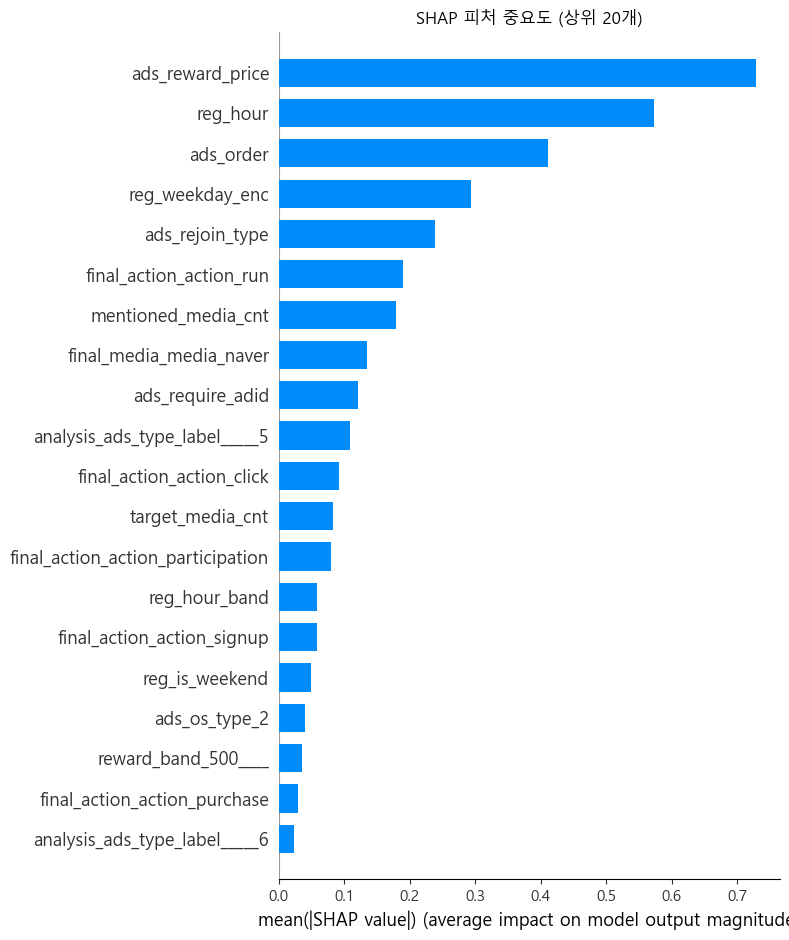

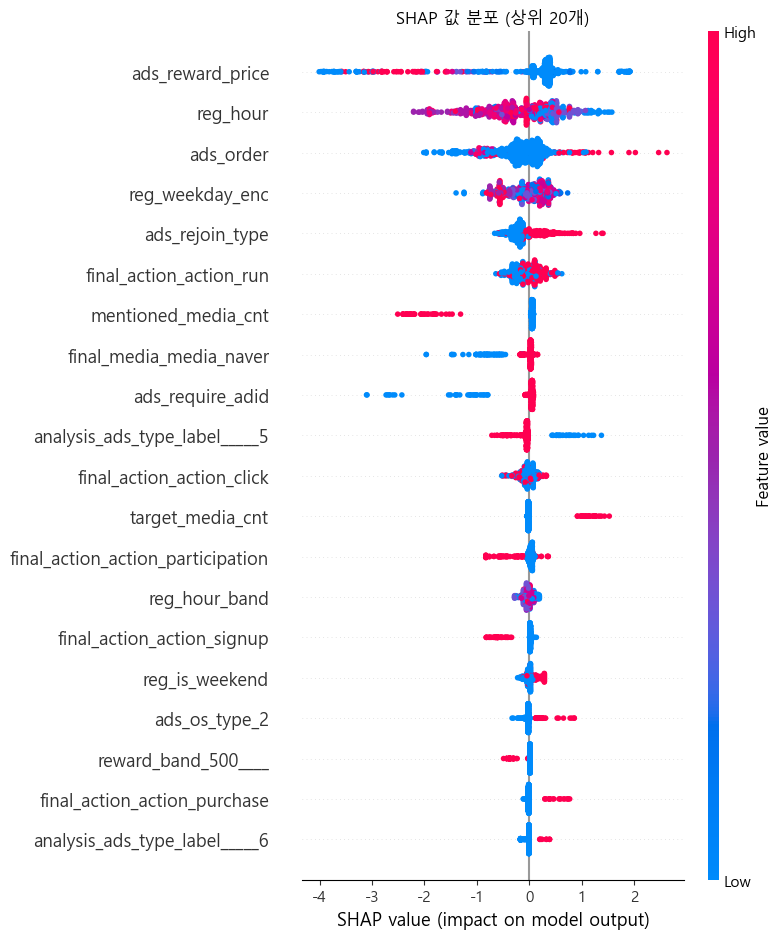


[SHAP 상위 10개]
   1. ads_reward_price: 0.7291
   2. reg_hour: 0.5736
   3. ads_order: 0.4111
   4. reg_weekday_enc: 0.2928
   5. ads_rejoin_type: 0.2392
   6. final_action_action_run: 0.1904
   7. mentioned_media_cnt: 0.1796
   8. final_media_media_naver: 0.1343
   9. ads_require_adid: 0.1205
  10. analysis_ads_type_label_____5: 0.1084

[피처 그룹별 SHAP 기여 비중]
  수치형: 75.3% (핵심 예측 신호)
  OHE:    24.7% (보조 정보)
  TF-IDF: 0.0% (추가 가치 미미)


In [16]:

try:
    import shap

    explainer   = shap.TreeExplainer(tuned_model)
    shap_values = explainer.shap_values(X_test_final)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test_final, plot_type='bar', show=False, max_display=20)
    plt.title('SHAP 피처 중요도 (상위 20개)')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test_final, show=False, max_display=20)
    plt.title('SHAP 값 분포 (상위 20개)')
    plt.tight_layout()
    plt.show()

    mean_abs = np.abs(sv).mean(0)
    top10 = sorted(zip(X_test_final.columns, mean_abs), key=lambda x: -x[1])[:10]
    print("\n[SHAP 상위 10개]")
    for rank, (feat, val_s) in enumerate(top10, 1):
        print(f"  {rank:2d}. {feat}: {val_s:.4f}")

    numeric_shap = sum(v for f, v in zip(X_test_final.columns, mean_abs)
                        if not f.startswith(('analysis_','reward_','final_','ads_os','tfidf_')))
    ohe_shap     = sum(v for f, v in zip(X_test_final.columns, mean_abs)
                        if f.startswith(('analysis_','reward_','final_','ads_os')))
    tfidf_shap   = sum(v for f, v in zip(X_test_final.columns, mean_abs)
                        if f.startswith('tfidf_'))
    total_shap   = numeric_shap + ohe_shap + tfidf_shap + 1e-9
    print(f"\n[피처 그룹별 SHAP 기여 비중]")
    print(f"  수치형: {numeric_shap/total_shap*100:.1f}% (핵심 예측 신호)")
    print(f"  OHE:    {ohe_shap/total_shap*100:.1f}% (보조 정보)")
    print(f"  TF-IDF: {tfidf_shap/total_shap*100:.1f}% (추가 가치 미미)")

except ImportError:
    print("pip install shap 후 재실행")


## 13. 품질 점수화

모델이 출력하는 고성과 예측 확률(0~1)을 0~100점 percentile rank로 변환한다.

확률값을 그대로 쓰지 않는 이유:
XGB는 특정 구간에 확률이 몰리는 경향이 있어 변별력이 낮다.
percentile rank는 0~100 전체에 고르게 분포해 등급 구분이 더 명확하다.

점수 변환 함수의 정의역(reference distribution):
점수 변환 함수는 train+val proba 분포만으로 정의한다.
test 예측 확률은 이 변환 함수에 단순 매핑되며, 자기 분포가 점수 정의에
영향을 주지 않는다. 이렇게 해야 train+val cutpoint를 test에 적용했을 때
test 분포가 점수화 단계에서 우회 유입되는 누수를 차단할 수 있다.


전체: 3,628건 (train+val: 2,902 | test: 726)
점수 변환 reference: train+val proba (2,902건) — test는 매핑만 수행

[예측 확률 분포]
count    3628.0000
mean        0.3782
std         0.3119
min         0.0002
10%         0.0120
25%         0.0603
50%         0.3351
75%         0.6490
90%         0.7936
max         0.9892
Name: proba, dtype: float64

[구간별 확률 분포 — 몰림 현상 확인]
proba
(-0.00079, 0.0991]    1133
(0.0991, 0.198]        293
(0.198, 0.297]         298
(0.297, 0.396]         226
(0.396, 0.495]         193
(0.495, 0.594]         363
(0.594, 0.692]         352
(0.692, 0.791]         390
(0.791, 0.89]          152
(0.89, 0.989]          228
Name: count, dtype: int64

[split별 quality_pred_score 분포]
  split     mean    P25    P50    P75    P90
  train     50.6   25.0   51.0   76.1   90.6
  val       48.3   25.1   47.6   70.7   87.2
  test      51.8   30.2   53.0   76.6   89.2


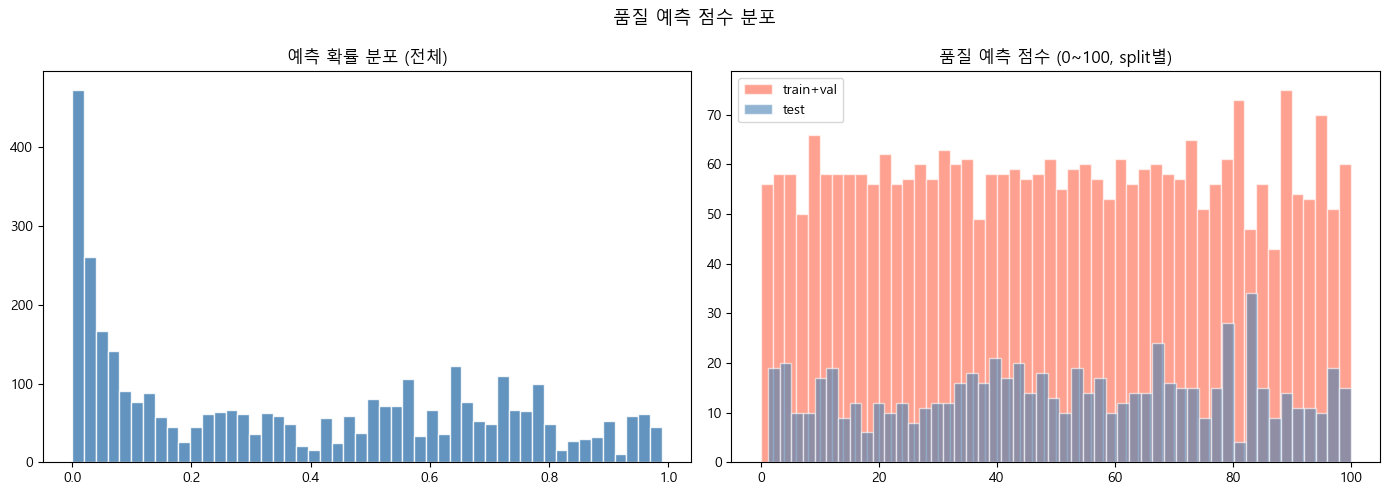

In [17]:

# split별 proba 예측
all_dfs = []
for name, df, feats in [
    ('train', FINAL_TRAIN, FINAL_FEATS),
    ('val',   FINAL_VAL,   FINAL_FEATS),
    ('test',  test_final,  FINAL_FEATS),
]:
    proba = tuned_model.predict_proba(df[feats])[:, 1]
    tmp = df[['ads_idx','label']].copy()
    tmp['proba'] = proba
    tmp['split'] = name
    all_dfs.append(tmp)

all_pred = pd.concat(all_dfs, ignore_index=True)

# 점수 변환 함수의 reference 분포 = train+val proba (test는 정의에 개입 X)
mask_tv   = all_pred['split'].isin(['train','val'])
mask_test = all_pred['split'] == 'test'
ref_proba_sorted = np.sort(all_pred.loc[mask_tv, 'proba'].values)
N_REF = len(ref_proba_sorted)

def proba_to_score(p_array, ref_sorted):
    """train+val proba 경험적 CDF에 매핑해 0~100 점수로 변환."""
    return np.searchsorted(ref_sorted, p_array, side='right') / len(ref_sorted) * 100

# train+val: 자기 자신 분포에서 percentile rank
all_pred['quality_pred_score'] = np.nan
all_pred.loc[mask_tv, 'quality_pred_score'] = (
    all_pred.loc[mask_tv, 'proba'].rank(pct=True) * 100
).round(1)

# test: train+val 경험적 CDF에 매핑
all_pred.loc[mask_test, 'quality_pred_score'] = np.round(
    proba_to_score(all_pred.loc[mask_test, 'proba'].values, ref_proba_sorted),
    1
)

print(f"전체: {len(all_pred):,}건 (train+val: {mask_tv.sum():,} | test: {mask_test.sum():,})")
print(f"점수 변환 reference: train+val proba ({N_REF:,}건) — test는 매핑만 수행")

print("\n[예측 확률 분포]")
print(all_pred['proba'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4))

print("\n[구간별 확률 분포 — 몰림 현상 확인]")
print(pd.cut(all_pred['proba'], bins=10).value_counts().sort_index())

# split별 점수 분포 — 변환 일관성 검증
print("\n[split별 quality_pred_score 분포]")
print(f"  {'split':<6} {'mean':>7} {'P25':>6} {'P50':>6} {'P75':>6} {'P90':>6}")
for s in ['train','val','test']:
    s_score = all_pred.loc[all_pred['split']==s, 'quality_pred_score']
    print(f"  {s:<6} {s_score.mean():>7.1f} {s_score.quantile(.25):>6.1f} "
          f"{s_score.quantile(.50):>6.1f} {s_score.quantile(.75):>6.1f} "
          f"{s_score.quantile(.90):>6.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('품질 예측 점수 분포', fontsize=13)
axes[0].hist(all_pred['proba'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('예측 확률 분포 (전체)')
axes[1].hist(all_pred.loc[mask_tv, 'quality_pred_score'], bins=50,
             color='tomato', edgecolor='white', alpha=0.6, label='train+val')
axes[1].hist(all_pred.loc[mask_test, 'quality_pred_score'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.6, label='test')
axes[1].set_title('품질 예측 점수 (0~100, split별)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 14. 등급화 (train+val cutpoint 기준, test 적용)

등급화 단계의 처리 흐름:
1. 점수 변환 함수: train+val proba 분포만으로 정의 (Step 13에서 확정)
2. 등급 cutpoint:    train+val 점수 분포에서 qcut으로 산출
3. test 적용:       동일 변환 함수와 동일 cutpoint로 점수화·등급화

이 흐름에서는 점수와 cutpoint 모두 train+val에서만 결정되므로,
test 분포가 어느 단계에도 개입하지 않는다.


In [18]:
print(len(all_pred))        # 전체 몇 건?
print(all_pred['split'].value_counts())  # train/val/test 각각 몇 건?

3628
split
train    2176
val       726
test      726
Name: count, dtype: int64


[train+val 확률 분포]
  std: 0.3134 | 20~80% 범위: 0.6750
확률 분포 고름 -> 5등급 (분위수 기반)

[등급별 고성과율 — test only 기준]
등급           건수       비율       고성과 비율
--------------------------------------
  S등급       721건     19.9%        68.2%
  A등급       724건     20.0%        34.7%
  B등급       761건     21.0%        14.6%
  C등급       711건     19.6%         3.2%
  D등급       711건     19.6%         0.7%


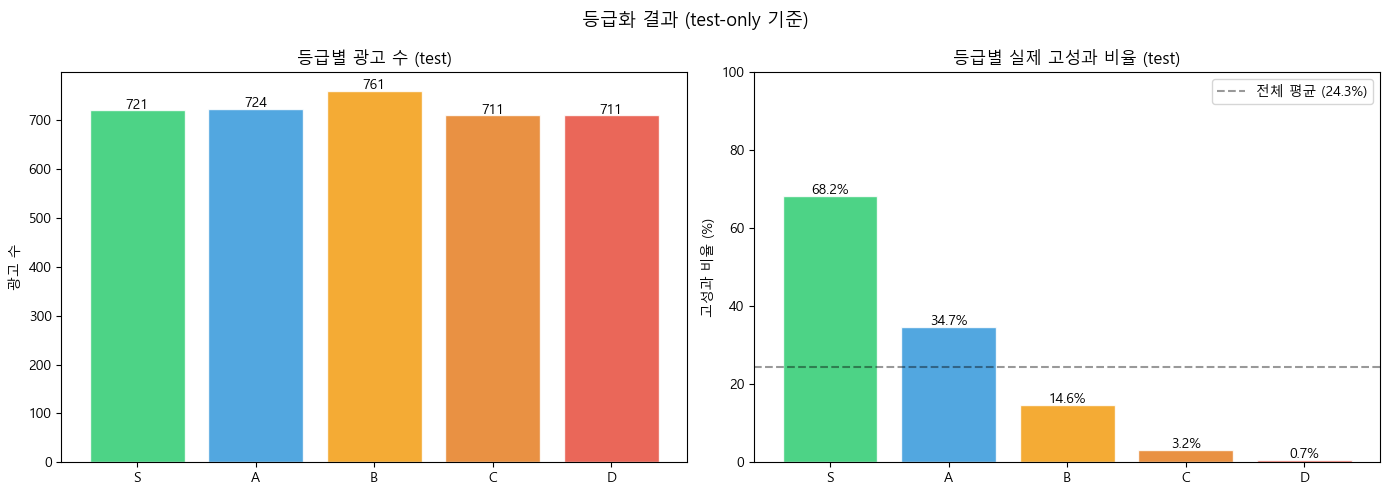

In [19]:

# train+val 기준으로 cutpoint 확정 (점수 변환 함수도 이미 train+val 기준)
train_val_pred = all_pred[all_pred['split'].isin(['train','val'])].copy()
test_pred = all_pred.copy()  

proba_std   = train_val_pred['proba'].std()
proba_range = train_val_pred['proba'].quantile(0.8) - train_val_pred['proba'].quantile(0.2)

print(f"[train+val 확률 분포]")
print(f"  std: {proba_std:.4f} | 20~80% 범위: {proba_range:.4f}")

# 5등급 가능 여부 확인 (std > 0.15, 범위 > 0.20)
if proba_std > 0.15 and proba_range > 0.20:
    print("확률 분포 고름 -> 5등급 (분위수 기반)")
    _, bins = pd.qcut(train_val_pred['quality_pred_score'], q=5,
                       retbins=True, duplicates='drop')
    # bins 양 끝을 [0, 100]으로 안전 확장 — test 점수가 train+val 분포 끝단을 벗어나도 NaN 방지
    bins = np.array(bins, dtype=float)
    bins[0]  = min(bins[0], 0.0)
    bins[-1] = max(bins[-1], 100.0)
    n_bins = len(bins) - 1
    all_labels = ['D','C','B','A','S']
    labels = all_labels[-n_bins:]
    grade_order = ['S','A','B','C','D'][:n_bins]
else:
    print("확률 분포 몰림 -> 3등급 (확률 분위수 기반)")
    q60 = train_val_pred['proba'].quantile(0.60)
    q20 = train_val_pred['proba'].quantile(0.20)
    bins = None
    grade_order = ['A','B','C']

# train+val에 등급 적용 (cutpoint 확정용)
if bins is not None:
    train_val_pred['grade'] = pd.cut(train_val_pred['quality_pred_score'],
                                      bins=bins, labels=labels, include_lowest=True)
else:
    train_val_pred['grade'] = 'B'
    train_val_pred.loc[train_val_pred['proba'] >= q60, 'grade'] = 'A'
    train_val_pred.loc[train_val_pred['proba'] <  q20, 'grade'] = 'C'

# test에 동일 cutpoint 적용
if bins is not None:
    test_pred['grade'] = pd.cut(test_pred['quality_pred_score'],
                                 bins=bins, labels=labels, include_lowest=True)
    # 누락 방지: 모든 라벨을 카테고리로 보유
    test_pred['grade'] = test_pred['grade'].cat.add_categories(
        [g for g in ['S','A','B','C','D'] if g not in labels]
    )
    # 안전 점검: NaN 등급이 있으면 경고
    n_nan = test_pred['grade'].isna().sum()
    if n_nan > 0:
        print(f"경고: test 등급 미할당 {n_nan}건 (bins 범위 점검 필요)")
else:
    test_pred['grade'] = 'B'
    test_pred.loc[test_pred['proba'] >= q60, 'grade'] = 'A'
    test_pred.loc[test_pred['proba'] <  q20, 'grade'] = 'C'

# test-only 기준 고성과율 확인
print("\n[등급별 고성과율 — test only 기준]")
grade_dist = test_pred['grade'].value_counts().reindex(grade_order, fill_value=0)
grade_pct  = grade_dist / len(test_pred) * 100

print(f"{'등급':<6} {'건수':>8} {'비율':>8} {'고성과 비율':>12}")
print("-" * 38)
for g in grade_order:
    mask = test_pred['grade'] == g
    cnt  = mask.sum()
    pct  = cnt / len(test_pred) * 100
    pos  = test_pred.loc[mask, 'label'].mean() * 100 if cnt > 0 else 0
    print(f"  {g}등급  {cnt:>8,}건  {pct:>7.1f}%  {pos:>10.1f}%")

# 시각화
colors_g = {'S':'#2ecc71','A':'#3498db','B':'#f39c12','C':'#e67e22','D':'#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('등급화 결과 (test-only 기준)', fontsize=13)

ax = axes[0]
vals = grade_dist.reindex(grade_order, fill_value=0).values
ax.bar(grade_order, vals,
       color=[colors_g.get(g,'gray') for g in grade_order],
       edgecolor='white', alpha=0.85)
for i, (g, v) in enumerate(zip(grade_order, vals)):
    ax.text(i, v+3, str(v), ha='center', fontsize=10)
ax.set_title('등급별 광고 수 (test)')
ax.set_ylabel('광고 수')

ax = axes[1]
actual_pos = []
for g in grade_order:
    mask = test_pred['grade'] == g
    actual_pos.append(test_pred.loc[mask,'label'].mean()*100 if mask.sum()>0 else 0)
ax.bar(grade_order, actual_pos,
       color=[colors_g.get(g,'gray') for g in grade_order],
       edgecolor='white', alpha=0.85)
for i, v in enumerate(actual_pos):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)
ax.axhline(test_pred['label'].mean()*100, color='black', linestyle='--',
            alpha=0.4, label=f'전체 평균 ({test_pred["label"].mean()*100:.1f}%)')
ax.set_title('등급별 실제 고성과 비율 (test)')
ax.set_ylabel('고성과 비율 (%)')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()


## 15. 최종 결과 요약

In [20]:

print("=" * 65)
print("Model 1 최종 결과 요약")
print("=" * 65)
print(f"\n[모델 정의]")
print(f"  광고 등록 시점 속성으로 최종 고성과(품질 상위 25%) 예측")
print(f"  적용 대상: 유효 클릭(>=10건) 확보 광고")
print()
print(f"[최종 모델]")
print(f"  [full] XGB")
print(f"  피처: {BEST_EXP_FULL} ({len(FINAL_FEATS)}개)")
print(f"  val AUC:       {roc_auc_score(y_va_f, va_proba_tuned):.4f}")
print(f"  test AUC:      {te_auc:.4f}")
print(f"  test PR-AUC:   {te_prauc:.4f}")
print(f"  train-test gap:{te_gap:.4f}")
gap_to_target = TARGET_AUC - te_auc
auc_status = '달성' if te_auc >= TARGET_AUC else f'미달 ({gap_to_target:.4f} 부족)'
print(f"  목표 AUC {TARGET_AUC}: {auc_status}")
print()
print(f"[민감도 분석 — 이상치 제외 clean 참고값]")
try:
    print(f"  clean test AUC:    {te_auc_clean:.4f} (full 대비 {te_auc_clean-te_auc:+.4f})")
    print(f"  clean test PR-AUC: {te_prauc_clean:.4f} (full 대비 {te_prauc_clean-te_prauc:+.4f})")
except:
    print(f"  Step 11 실행 후 확인 가능")
print()
print(f"[등급화 결과 — test-only 기준]")
for g in grade_order:
    mask = test_pred['grade'] == g
    cnt  = mask.sum()
    pct  = cnt / len(test_pred) * 100
    pos  = test_pred.loc[mask, 'label'].mean() * 100 if cnt > 0 else 0
    print(f"  {g}등급: {cnt:,}건 ({pct:.1f}%) | 고성과 {pos:.1f}%")
print()
print(f"[피처 실험 요약 (full, val_auc 정렬)]")
print(result_full[['experiment','n_features','val_auc','cv_mean','cv_std','gap','status']]
      .sort_values('val_auc', ascending=False).to_string(index=False))
print()
print(f"[모델 비교 요약 (val_auc 정렬)]")
print(df_all[['version','model','val_auc','cv_mean','cv_std','gap','status']]
      .sort_values('val_auc', ascending=False).to_string(index=False))


Model 1 최종 결과 요약

[모델 정의]
  광고 등록 시점 속성으로 최종 고성과(품질 상위 25%) 예측
  적용 대상: 유효 클릭(>=10건) 확보 광고

[최종 모델]
  [full] XGB
  피처: B_num+ohe (48개)
  val AUC:       0.8094
  test AUC:      0.8347
  test PR-AUC:   0.6221
  train-test gap:0.0777
  목표 AUC 0.75: 달성

[민감도 분석 — 이상치 제외 clean 참고값]
  clean test AUC:    0.8279 (full 대비 -0.0068)
  clean test PR-AUC: 0.6132 (full 대비 -0.0088)

[등급화 결과 — test-only 기준]
  S등급: 721건 (19.9%) | 고성과 68.2%
  A등급: 724건 (20.0%) | 고성과 34.7%
  B등급: 761건 (21.0%) | 고성과 14.6%
  C등급: 711건 (19.6%) | 고성과 3.2%
  D등급: 711건 (19.6%) | 고성과 0.7%

[피처 실험 요약 (full, val_auc 정렬)]
       experiment  n_features  val_auc  cv_mean  cv_std    gap  status
      F_no_action          90   0.8261   0.8254  0.0283 0.1373 CAUTION
           C_full          98   0.8259   0.8293  0.0226 0.1424 CAUTION
      D_num+tfidf          64   0.8250   0.8236  0.0275 0.1385 CAUTION
G_num+ohe_notfidf          48   0.8047   0.8102  0.0228 0.1316 CAUTION
        B_num+ohe          48   0.8047   0.8102  0.0228 0.131